In [ ]:
!nvidia-smi

Sat Jul  5 09:50:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install transformers accelerate>=0.20.3


In [ ]:
!pip install -U datasets
!pip install fsspec==2023.9.2

In [ ]:
!pip install -U evaluate


In [ ]:
!pip install sacrebleu
import os
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
)

# === Configuration
model_name = "monirbishal/en-bn-nmt"
output_dir = "fine-tuned-en-bn-updated"

# === Prepare model & tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# === Load and preprocess data
data_path = "/content/sample_data/all-data.json"
dataset = load_dataset("json", data_files={"train": data_path})["train"]

def preprocess(ex):
    enc = tokenizer(ex["en"], truncation=True, padding="max_length", max_length=128)
    dec = tokenizer(text_target=ex["bn"], truncation=True, padding="max_length", max_length=128)
    enc["labels"] = dec["input_ids"]
    return enc
tokenized = dataset.map(preprocess, batched=True, remove_columns=["en", "bn"])
ds = tokenized.train_test_split(test_size=0.1)

# === Collator & Metric
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
sacrebleu = evaluate.load("sacrebleu")
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple): preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    return {"bleu": sacrebleu.compute(predictions=decoded_preds, references=[[l] for l in decoded_labels])["score"]}

# === Training Arguments
args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",  # Use 'eval_strategy' instead of 'evaluation_strategy'
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    save_total_limit=2,
    predict_with_generate=True,
    fp16=True,
    logging_steps=50,
    overwrite_output_dir=True,
    report_to="none"  # Disable W&B integration
)


# === Trainer and Training
trainer = Seq2SeqTrainer(
    model=model, args=args,
    train_dataset=ds["train"], eval_dataset=ds["test"],
    tokenizer=tokenizer, data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

# === Save the updated model
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print("✅ Training complete. Model saved to", output_dir)


# Testing model and show reports

In [ ]:
import evaluate
import numpy as np

# Load the sacrebleu metric
sacrebleu = evaluate.load("sacrebleu")

# Define a function to compute BLEU score
def compute_bleu(predictions, references):
    decoded_preds = [tokenizer.decode(pred, skip_special_tokens=True) for pred in predictions]
    decoded_refs = [[tokenizer.decode(ref, skip_special_tokens=True)] for ref in references]
    return sacrebleu.compute(predictions=decoded_preds, references=decoded_refs)["score"]

# Evaluate the original model
original_preds = trainer.predict(ds["test"]).predictions
original_bleu = compute_bleu(original_preds, ds["test"]["labels"])

# Evaluate the fine-tuned model
trainer.model = model  # Ensure the trainer uses the fine-tuned model
fine_tuned_preds = trainer.predict(ds["test"]).predictions
fine_tuned_bleu = compute_bleu(fine_tuned_preds, ds["test"]["labels"])

print(f"Original Model BLEU: {original_bleu}")
print(f"Fine-Tuned Model BLEU: {fine_tuned_bleu}")


Original Model BLEU: 33.14805680286356
Fine-Tuned Model BLEU: 33.14805680286356


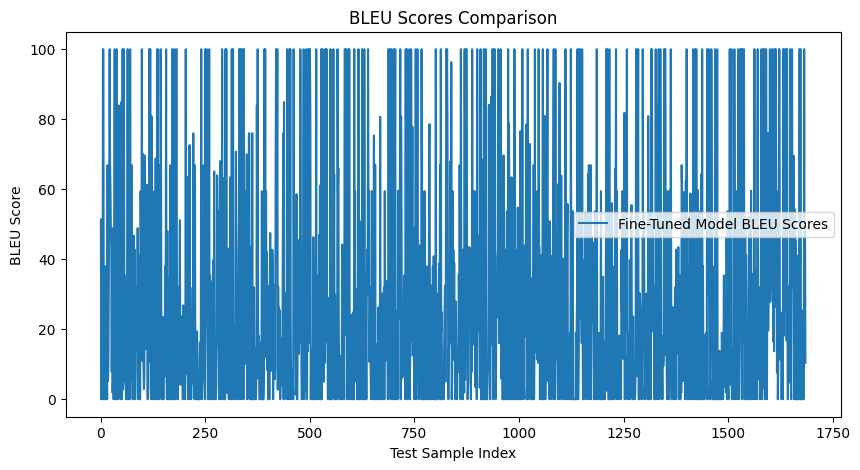

In [ ]:
import matplotlib.pyplot as plt

# Decode predictions
original_decoded = [tokenizer.decode(pred, skip_special_tokens=True) for pred in original_preds]
fine_tuned_decoded = [tokenizer.decode(pred, skip_special_tokens=True) for pred in fine_tuned_preds]
references = [tokenizer.decode(ref, skip_special_tokens=True) for ref in ds["test"]["labels"]]

# Plot BLEU scores for each sample
bleu_scores = [compute_bleu([pred], [ref]) for pred, ref in zip(fine_tuned_preds, ds["test"]["labels"])]

plt.figure(figsize=(10, 5))
plt.plot(bleu_scores, label="Fine-Tuned Model BLEU Scores")
plt.title("BLEU Scores Comparison")
plt.xlabel("Test Sample Index")
plt.ylabel("BLEU Score")
plt.legend()
plt.show()
